# Experiment 1: SMOTE Oversampling

## Financial Fraud Detection

### Objective

Evaluate the performance of Logistic Regression using **SMOTE (Synthetic Minority Oversampling Technique)** to handle class imbalance.

This notebook serves as the baseline experiment for comparing different imbalance handling techniques.

## Import Libraries

In [82]:
import os

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

## Load Dataset

In [83]:
df = pd.read_csv("../../data/processed/creditcard_feature_engineered.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Large_Transaction,Log_Amount,Amount_Level
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0,0,5.014760,3
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0,0,1.305626,0
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0,1,5.939276,3
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0,0,4.824306,3
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0,0,4.262539,2


## Dataset Information

In [84]:
print("Shape :", df.shape)

df.info()

Shape : (283726, 34)
<class 'pandas.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 34 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Time               283726 non-null  float64
 1   V1                 283726 non-null  float64
 2   V2                 283726 non-null  float64
 3   V3                 283726 non-null  float64
 4   V4                 283726 non-null  float64
 5   V5                 283726 non-null  float64
 6   V6                 283726 non-null  float64
 7   V7                 283726 non-null  float64
 8   V8                 283726 non-null  float64
 9   V9                 283726 non-null  float64
 10  V10                283726 non-null  float64
 11  V11                283726 non-null  float64
 12  V12                283726 non-null  float64
 13  V13                283726 non-null  float64
 14  V14                283726 non-null  float64
 15  V15                283726 non-null  float

## Encode ALL Categorical Columns (Important)

In [85]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns")

print(categorical_columns)

Categorical Columns
Index([], dtype='str')


In [86]:
encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("Encoding Complete")

Encoding Complete


## Verify Dataset

In [87]:
print(df.dtypes.unique())

[dtype('float64') dtype('int64')]


## Encode Amount_Level

## Separate Features and Target

In [88]:
X = df.drop("Class", axis=1)

y = df["Class"]

## Train-Test Split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Verify Class Distribution

In [90]:
print("Training")

print(y_train.value_counts())

print()

print("Testing")

print(y_test.value_counts())

Training
Class
0    226602
1       378
Name: count, dtype: int64

Testing
Class
0    56651
1       95
Name: count, dtype: int64


## Apply SMOTE

In [91]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

## Verify Balanced Dataset

In [92]:
print(y_train_smote.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


## Train Logistic Regression

In [93]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Make Predictions

In [94]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

## Accuracy

In [95]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9784


## Precision

In [96]:
precision = precision_score(
    y_test,
    y_pred
)

print(f"Precision : {precision:.4f}")

Precision : 0.0633


## Recall

In [97]:
recall = recall_score(
    y_test,
    y_pred
)

print(f"Recall : {recall:.4f}")

Recall : 0.8632


## F1 Score

In [98]:
f1 = f1_score(
    y_test,
    y_pred
)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.1179


## Classification Report

In [99]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.86      0.12        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



## Confusion Matrix

In [100]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[55437  1214]
 [   13    82]]


## ROC-AUC

In [101]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC : {roc_auc:.4f}")

ROC-AUC : 0.9506


## ROC Curve

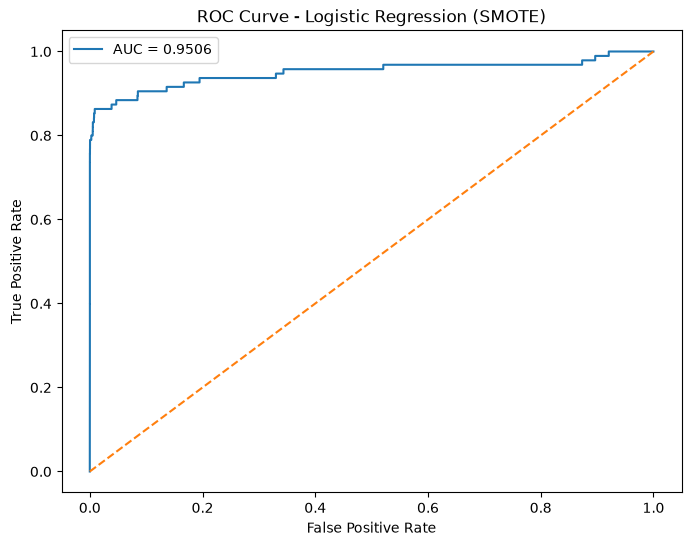

In [102]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression (SMOTE)")

plt.legend()

plt.show()

## Save Metrics

In [103]:
smote_results = pd.DataFrame({

    "Technique":["SMOTE"],

    "Accuracy":[accuracy],

    "Precision":[precision],

    "Recall":[recall],

    "F1 Score":[f1],

    "ROC-AUC":[roc_auc]

})

smote_results.to_csv(
    "../../results/smote_metrics.csv",
    index=False
)

print("SMOTE metrics saved successfully.")

SMOTE metrics saved successfully.


In [104]:
os.makedirs("../../models", exist_ok=True)

joblib.dump(
    model,
    "../../models/logistic_regression_smote.pkl"
)

print("Model saved successfully.")

Model saved successfully.


# Final Observation

- Successfully applied SMOTE to balance the training dataset.
- Trained a Logistic Regression model using the balanced data.
- Evaluated the model using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC.
- Saved the evaluation metrics for comparison with other imbalance handling techniques.
- Saved the trained model for future use.